# 05. Avaliação Detalhada e Seleção do Modelo Final

## Contexto e Definição de Métricas
Nesta etapa, o modelo com melhor desempenho na validação cruzada (**Logistic Regression**) é submetido ao conjunto de teste não visto.

### Métricas de Avaliação Aplicadas:
1. **Acurácia (Accuracy):** Proporção geral de acertos do modelo em relação ao total de previsões.
2. **Precisão (Precision):** Proporção de verdadeiros positivos em relação ao total de predições positivas. Mede a taxa de falsos alarmes.
3. **Revocação (Recall / Sensibilidade):** Proporção de casos positivos identificados corretamente em relação ao total real de casos positivos. No contexto médico, o **Recall é a métrica crítica**, pois um falso negativo implica deixar de diagnosticar um paciente doente.
4. **F1-Score:** Média harmônica entre Precisão e Recall, útil para avaliar o equilíbrio entre as duas métricas.
5. **Curva ROC e AUC (Area Under the Curve):** Avalia a capacidade de discriminação entre as duas classes em diferentes limiares de decisão.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay, roc_auc_score
import joblib

# Carregamento dos dados pré-processados
data = np.load("../data/processed/train_test_data.npz")
X_train, X_test = data['X_train'], data['X_test']
y_train, y_test = data['y_train'], data['y_test']

print(f"Dados de treino e teste carregados:")
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

Dados de treino e teste carregados:
X_train: (242, 28) | X_test: (61, 28)


## 1. Treinamento do Modelo Campeão e Gerado de Predições

Ajustamos o modelo de Regressão Logística no conjunto de treino completo e extraímos tanto as classes previstas (`y_pred`) quanto as probabilidades associadas (`y_proba`).

In [2]:
# Instanciação e treinamento do modelo escolhido
best_model = LogisticRegression(max_iter=1000, random_state=42)
best_model.fit(X_train, y_train)

# Predições nos dados de teste
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

## 2. Relatório de Classificação Detalhado

Análise do desempenho ponderado por classe (Saudável vs. Doente).

In [3]:
print("--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred, target_names=["Saudável (0)", "Doente (1)"]))

--- Relatório de Classificação ---
              precision    recall  f1-score   support

Saudável (0)       0.93      0.85      0.89        33
  Doente (1)       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



## 3. Matriz de Confusão

A matriz de confusão nos permite visualizar exatamente onde o modelo cometeu erros:
- **Verdadeiros Negativos (TN):** Pacientes saudáveis previstos como saudáveis.
- **Falsos Positivos (FP):** Pacientes saudáveis previstos erroneamente como doentes.
- **Falsos Negativos (FN):** Pacientes doentes previstos erroneamente como saudáveis.
- **Verdadeiros Positivos (TP):** Pacientes doentes previstos como doentes.

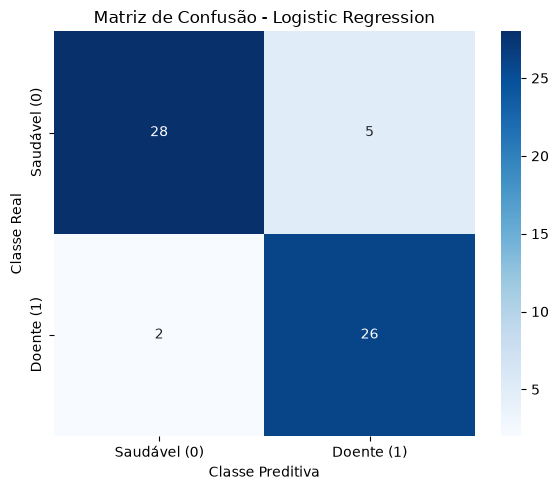

In [4]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=["Saudável (0)", "Doente (1)"], 
    yticklabels=["Saudável (0)", "Doente (1)"]
)
plt.title("Matriz de Confusão - Logistic Regression")
plt.ylabel("Classe Real")
plt.xlabel("Classe Preditiva")
plt.tight_layout()
plt.show()

## 4. Curva ROC e Métrica AUC

Plotagem da relação entre a taxa de verdadeiros positivos e a taxa de falsos positivos em vários níveis de corte (*thresholds*).

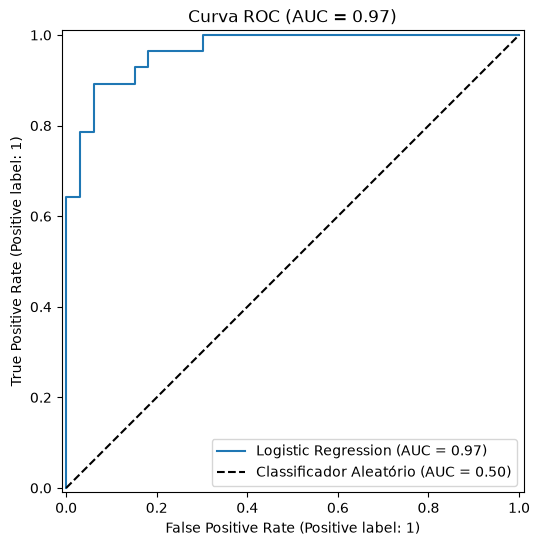

Pontuação ROC AUC Final: 0.9665


In [5]:
auc_score = roc_auc_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=ax, name="Logistic Regression")
plt.title(f"Curva ROC (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], "k--", label="Classificador Aleatório (AUC = 0.50)")
plt.legend()
plt.show()

print(f"Pontuação ROC AUC Final: {auc_score:.4f}")

## 5. Exportação do Artefato Final

Exportação do modelo treinado utilizando `joblib` para o diretório `models/`, permitindo sua utilização no notebook de inferência.

In [6]:
# Salvamento do modelo treinado
joblib.dump(best_model, "../models/best_model.joblib")
print("Modelo serializado com sucesso em: ../models/best_model.joblib")

Modelo serializado com sucesso em: ../models/best_model.joblib
